## Fitting auditory population activity

This tutorial will show you how to fit a model on the **NS1 dataset** in *population coding* mode.

Let's start with some boilerplate imports.

In [1]:
import os
import wandb
import torch.utils

from deepSTRF.datasets.audio import NS1_DRC_Dataset
from deepSTRF.models.audio import ConvNet2D
from deepSTRF.utils.training_pop import optimize_multiple_seeds

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


Let's check whether a GPU is available for PyTorch. 

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"\nSelected device: {device}\n")


Selected device: cpu



Define where you would like to work: save model checkpoints, etc.

In [3]:
root = '/home/ulysse/PycharmProjects/deepSTRF/deepSTRF/'  # change path manually

Let's now instanciate the dataset. For this, we need to define the path to the data (cf. NS1 dataset setup instructions).

In [4]:
# dataset
dataset_root = root + 'datasets/audio/NS1_DRC/data'
neuron_indices = tuple(range(73))
dataset = NS1_DRC_Dataset(path=dataset_root, stimuli=('nat',), neuron_indexes=neuron_indices, normalize_resps=False)
F = dataset.get_F()     # number of spectrogram frequency bands
N = dataset.get_N()     # total number of available neurons to fit in the dataset

/home/ulysse/PycharmProjects/deepSTRF/deepSTRF/datasets/audio/NS1_DRC_Dataset.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  spectrograms = torch.load(os.path.join(pat

We also need to define a function to split the data into train, validation and test set, given our instanciated datasets. NS1 dataset has a total of 20 stimuli, so let's do a 14-2-4 split.

In [5]:
def data_split_func(dataset):
    train_set, valid_set, test_set = torch.utils.data.random_split(dataset, [14, 2, 4])
    return train_set, valid_set, test_set

Let's also define our training hyperparameters

In [6]:
# optimization
seeds = list(range(1))
n_epochs_early_stop = 50
batch_size = 1  # usually best small for small datasets
learning_rate = 0.001
weight_decay = 0.
criterion = torch.nn.MSELoss()

Now we can instanciate our model. Similar to above, we need to wrap this into a function which will be used at the beginning of the training process in different random seeds.

In [7]:
# prefiltering / parameterization (if applies) / model architecture hyperparameters
T = 43  # Temporal window size
prefilt_dict = {'type': 'AdapTrans', 'dt': 10.0, 'min_freq': 500, 'max_freq': 20000, 'scale': 'mel'}
param_dict = {'type': 'DCLS', 'num_gauss': 10}
def model_init_fn():
    """ change it as you like """
    # model = Linear(n_frequency_bands=F, temporal_window_size=T, out_neurons=N, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = LinearNonlinear(n_frequency_bands=49, temporal_window_size=T, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = NetworkReceptiveField(n_frequency_bands=49, temporal_window_size=T, n_hidden=20, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = DNet(n_frequency_bands=F, temporal_window_size=T, n_hidden=20, init_tau=2., prefiltering=prefilt_dict, parameterization=param_dict)
    model = ConvNet2D(n_frequency_bands=F, kernel_size=(3, 15), c_hidden=10, n_hidden=90, out_neurons=N, prefiltering=None)
    model = model.to(device)
    return model
net = model_init_fn()
print(net)

ConvNet2D(
  (convs): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(10, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Conv2d(10, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (7): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1)
  )
  (fc): Sequential(
    (0): Linear(in_features=280, out_features=90, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=90, out_features=73, bias=True)
  )
  (activation): Sigmoid()
)


Log some hyperparameter values about the run on wandb; feel free to adapt it to your liking.

In [8]:
# Weights & Biases logging
os.environ["WANDB_MODE"] = "offline"  # comment out for online logging
project_name = 'deepSTRF'
entity_name = 'urancon'
config = {
    "seeds": seeds,
    "temporal_window_size": T,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "model": net.__class__.__name__,
    "Nb of parameters": net.count_trainable_params(),
    "Dataset": dataset.__class__.__name__
}
wandb.init(project=project_name, entity=entity_name, config=config)
print(f"Model: {net.__class__.__name__}, # params: {net.count_trainable_params()}")

Model: ConvNet2D, # params: 41473


In [9]:
# create folder for model saves
savedir = os.path.join(root, f'results/{dataset.__class__.__name__}/{net.__class__.__name__}/')
if not os.path.exists(savedir):
    os.makedirs(savedir)

We are finally ready to launch the training process. We first need to define which neurons (i.e., our population) we want to fit our model on.

In [10]:
print("\n#### POPULATION ####\n")
print("Neuron indices:\n", neuron_indices)
dataset.select_population(neuron_indices)# train model on multiple splits of this population's data and average results


#### POPULATION ####

Neuron indices:
 (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72)


In [11]:
pop_res_dict = optimize_multiple_seeds(0, seeds, dataset,
                                       data_split_func, model_init_fn,
                                       criterion, learning_rate, weight_decay, batch_size, n_epochs_early_stop, device, savedir
                                       )


==== SEED 0 ====
{'best_epoch': 124, 'train_loss': 0.004357677884399891, 'train_CCraw': -1.0, 'train_CCnorm': -1.0, 'val_loss': 0.004825097043067217, 'val_CCraw': 0.5310014486312866, 'val_CCnorm': 0.7327319383621216, 'test_loss': 0.006101570092141628, 'test_CCraw': 0.5477574467658997, 'test_CCnorm': 0.7147718667984009}


/home/ulysse/PycharmProjects/deepSTRF/deepSTRF/utils/training_pop.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(savedir))


We got a CCnorm of 71% on the test set; not bad at all! 

Let's check what a prediction looks like on a random stimulus sample for a given neuron.
For this, we must load the best model checkpoint first.

In [11]:
net.load_state_dict(torch.load(savedir + f"nrn0_seed{seeds[0]}.pt"))
net.eval()

/tmp/ipykernel_47587/2656651160.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(savedir + f"nrn0_seed{seeds[0]}.pt"))


ConvNet2D(
  (convs): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(10, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Conv2d(10, 10, kernel_size=(3, 15), stride=(1, 1), padding=(0, 7))
    (7): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1)
  )
  (fc): Sequential(
    (0): Linear(in_features=280, out_features=90, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=90, out_features=73, bias=True)
  )
  (activation): Sigmoid()
)

We can then take a sample from the dataset, forward it through the model, and display everything

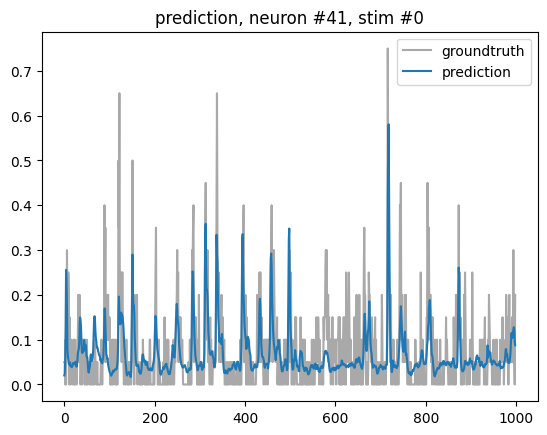

In [13]:
spectro, responses, nrn_mask = dataset[0]
spectro = spectro.unsqueeze(0).to(device) # add batch dimension: (1, F, T) --> (B, 1, F, T)
pred = net(spectro)  # (B, N, 1, T)
psth = responses.mean(dim=1)  # average over repeats to get the psth: (N, R, T) --> (N, T)


import matplotlib.pyplot as plt

tgt_nrn_idx = 41

plt.figure()
plt.title(f"prediction, neuron #{tgt_nrn_idx}, stim #0")
plt.plot(psth[tgt_nrn_idx].cpu(), label='groundtruth', color='darkgray')
plt.plot(pred[0, tgt_nrn_idx].detach().cpu(), label='prediction')
plt.legend()
plt.show()

What could be the CCnorm for a good example like this one ?

In [14]:
from deepSTRF.metrics import normalized_correlation_coefficient

pred = pred[:, :, :]
responses = responses.unsqueeze(0)
print(pred.shape, responses.shape)
ccnorm = normalized_correlation_coefficient(pred, responses)  # (N,)
print(ccnorm)

torch.Size([1, 73, 999]) torch.Size([1, 73, 20, 999])
tensor([0.8234, 0.8832, 0.8013, 0.8178, 0.7280, 0.8566, 0.8344, 0.7050, 0.8435,
        0.5271, 0.7559, 0.6825, 0.8352, 0.8731, 0.6989, 0.8911, 0.6863, 0.7994,
        0.7284, 0.7696, 0.6734, 0.6614, 0.7770, 0.6932, 0.8302, 0.7626, 0.8187,
        0.7884, 0.8287, 0.7148, 0.8411, 0.8615, 0.3577, 0.8879, 0.7950, 0.4814,
        0.8618, 0.8412, 0.7436, 0.8457, 0.7110, 0.8667, 0.6896, 0.6297, 0.7267,
        0.7008, 0.8383, 0.4406, 0.5854, 0.8443, 0.5319, 0.7840, 0.9062, 0.6326,
        0.7274, 0.7596, 0.7600, 0.6548, 0.5654, 0.8734, 0.3347, 0.4642, 0.8821,
        0.7482, 0.6068, 0.5905, 0.4089, 0.5434, 0.4490, 0.4455, 0.6409, 0.4952,
        0.6460])


In [26]:
strfs = net.STRF_gradmap(T=50)
print(strfs.shape)  # (N, 1, F, T)

torch.Size([73, 1, 34, 50])


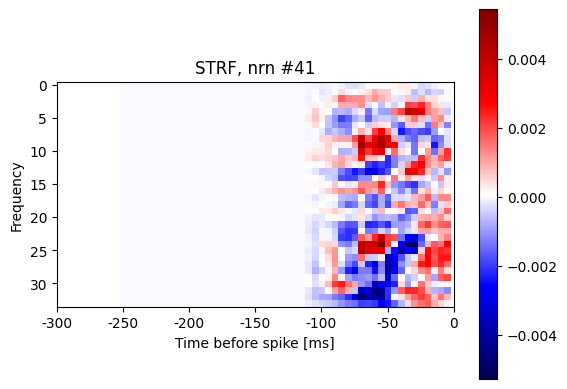

In [31]:
plt.figure()
plt.title(f"STRF, nrn #{tgt_nrn_idx}")
plt.imshow(strfs[tgt_nrn_idx, 0, :, :].cpu(), cmap='seismic')
plt.colorbar()
xticks = plt.xticks()[0]
xlabels = [int(-5 * (50 - x)) for x in xticks]
plt.xticks(ticks=xticks, labels=xlabels)
plt.xlabel("Time before spike [ms]")
plt.ylabel("Frequency")
plt.show()

Only the most recent stimulus time steps (to the right) contribute to the prediction of current neural activity, which makes sense. 
However, the boundary between the inside and the outside of the STRF is quite sharp, which is not super bio-plausible.